# $O(n)$

## 1. Import các thư viện

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath("../src"))
from utils import plot_execution_times, measure_algorithm_time, plot_comprehensive_barchart_grid, plot_danger_zone_heatmap, plot_algorithm_speedup_grid, calculate_baseline_n_log_n, plot_baseline_n_log_n
import random
import json
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Cấu hình tham số đồ thị
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

## 2. Cài đặt thuật toán có độ phức tạp $O(n)$

Trong nhóm độ phức tạp **O(n)**, hai thuật toán tiêu biểu và phù hợp nhất với dữ liệu số nguyên trong bài là **Counting Sort** và **Radix Sort**.

- **Counting Sort** tận dụng miền giá trị khóa để đếm tần suất, có độ phức tạp `O(n + k)` với `k` là giá trị khóa lớn nhất.
- **Radix Sort (LSD)** sắp xếp theo từng chữ số bằng Counting Sort ổn định, có độ phức tạp `O(d * (n + b))` với `d` là số chữ số, `b` là cơ số.

Nhóm chọn hai thuật toán này vì:

1. Cùng thuộc nhóm sắp xếp không dựa trên so sánh, đại diện tốt cho tư duy tuyến tính.
2. Dễ quan sát tác động của đặc tính dữ liệu đầu vào (ngẫu nhiên, gần sắp, nhiều trùng, sắp ngược).
3. Phù hợp trực tiếp với bộ dữ liệu `.npz` của đề bài (số nguyên không âm).

Mục tiêu của notebook là kiểm chứng thực nghiệm xu hướng tăng trưởng tuyến tính theo kích thước `n` và phân tích ưu/nhược điểm khi tham số miền giá trị thay đổi.

### 2.1 Counting sort

In [2]:
def counting_sort(arr):
    if len(arr) <= 1:
        return arr

    max_value = int(np.max(arr))
    count = np.zeros(max_value + 1, dtype=np.int64)

    for value in arr:
        count[int(value)] += 1

    index = 0
    for value, freq in enumerate(count):
        if freq > 0:
            arr[index:index + freq] = value
            index += freq

    return arr

### 2.2 Radix sort (Bonus)

In [3]:
def counting_sort_by_digit(arr, exp):
    n = len(arr)
    output = np.zeros(n, dtype=arr.dtype)
    count = np.zeros(10, dtype=np.int64)

    for i in range(n):
        digit = (int(arr[i]) // exp) % 10
        count[digit] += 1

    for i in range(1, 10):
        count[i] += count[i - 1]

    for i in range(n - 1, -1, -1):
        digit = (int(arr[i]) // exp) % 10
        output[count[digit] - 1] = arr[i]
        count[digit] -= 1

    arr[:] = output


def radix_sort(arr):
    if len(arr) <= 1:
        return arr

    max_value = int(np.max(arr))
    exp = 1

    while max_value // exp > 0:
        counting_sort_by_digit(arr, exp)
        exp *= 10

    return arr

## 3. Đọc dữ liệu từ file npz

In [4]:
sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']
base_path = '../data/' 

# Từ điển lưu trữ dữ liệu đã đọc: cấu trúc loaded_data['tên_dataset']['kích_thước']
loaded_data = {data_type: {} for data_type in datasets}

print("Đang tải dữ liệu lên bộ nhớ...")
for data_type in datasets:
    for size in sizes:
        folder_name = f'n_{size}'
        file_name = f'{data_type}_n{size}.npz'
        file_path = os.path.join(base_path, folder_name, file_name)
        
        try:
            npz_file = np.load(file_path)
            keys = npz_file.files
            # Lưu mảng dữ liệu vào từ điển
            loaded_data[data_type][size] = npz_file[keys[0]]
        except Exception as e:
            print(f"Lỗi với file {file_path}: {e}")
            loaded_data[data_type][size] = None

print("Đã tải xong toàn bộ dữ liệu!")

Đang tải dữ liệu lên bộ nhớ...
Đã tải xong toàn bộ dữ liệu!


## 4. Đo thời gian

#### Quy trình đo thời gian thực thi thuật toán

Để đảm bảo kết quả đo thời gian chính xác, ổn định và khách quan, nhóm thực hiện quy trình nội bộ theo các bước sau:

##### 1. Giai đoạn chuẩn bị (Warm-up)
- Trước khi đo chính thức, mỗi thuật toán được **chạy thử một lần trên mảng dữ liệu gốc**.  
- Mục đích: khởi động **CPU cache, bộ nhớ và cơ chế nội bộ của Python**, giảm thiểu ảnh hưởng của lần chạy đầu tiên có thể chậm do hệ thống hoặc bộ nhớ chưa tối ưu.  
- **Lưu ý:** Thời gian chạy warm-up **không tính vào kết quả đo**.

##### 2. Giai đoạn đo lường chính thức
- Mỗi thuật toán chạy trên **4 loại phân bố dữ liệu**:
  1. Ngẫu nhiên (Random)  
  2. Gần như đã sắp xếp (Nearly Sorted)  
  3. Nhiều khóa trùng (Many Duplicates)  
  4. Sắp ngược (Reversed)  
- Với mỗi **kích thước n** trong khoảng từ \(10^2\) đến \(10^5\), thuật toán được chạy **20 lần liên tiếp** để ghi nhận sự biến động thời gian.  
- Mỗi lần chạy sử dụng **một bản copy mới của mảng dữ liệu** để thuật toán luôn chạy trên dữ liệu gốc, tránh kết quả sai lệch do mảng đã sắp xếp.

##### 3. Xử lý và tính toán kết quả
- Thời gian thực thi của 20 lần chạy được ghi lại thành một danh sách.  
- Để loại bỏ **nhiễu hệ thống** (System Noise) như tiến trình khác chiếm CPU hoặc các outlier ngẫu nhiên, **trị số Median (trung vị)** của 20 lần chạy được sử dụng làm **thời gian thực thi chính thức** cho mỗi kịch bản.  
- Việc dùng Median giúp:
  - **Kháng nhiễu cao:** không bị ảnh hưởng bởi các outlier bất thường.  
  - **Phản ánh trung thực tốc độ thực thi nguyên bản của thuật toán**.

##### 4. Kiểm chứng đặc biệt
- Với thuật toán **Quick Sort**, cần theo dõi kỹ trên dữ liệu nhiều khóa trùng để phát hiện nguy cơ rơi vào **O(n²)**.  
- Nếu có sự suy biến, các kết quả này được **tách riêng để phân tích trực quan**.

### 4.1 Đo với thuật toán Counting sort

In [5]:
print("Đang đo Counting Sort...")
results_n = measure_algorithm_time(counting_sort, loaded_data, datasets, sizes, num_runs=20)

Đang đo Counting Sort...


### 4.2 Đo với thuật toán Radix sort

In [6]:
print("Đang đo Radix Sort")
results_n_bonus = measure_algorithm_time(radix_sort, loaded_data, datasets, sizes, num_runs=20)

Đang đo Radix Sort


## 5. Biểu đồ trực quan

### 5.1 Counting sort

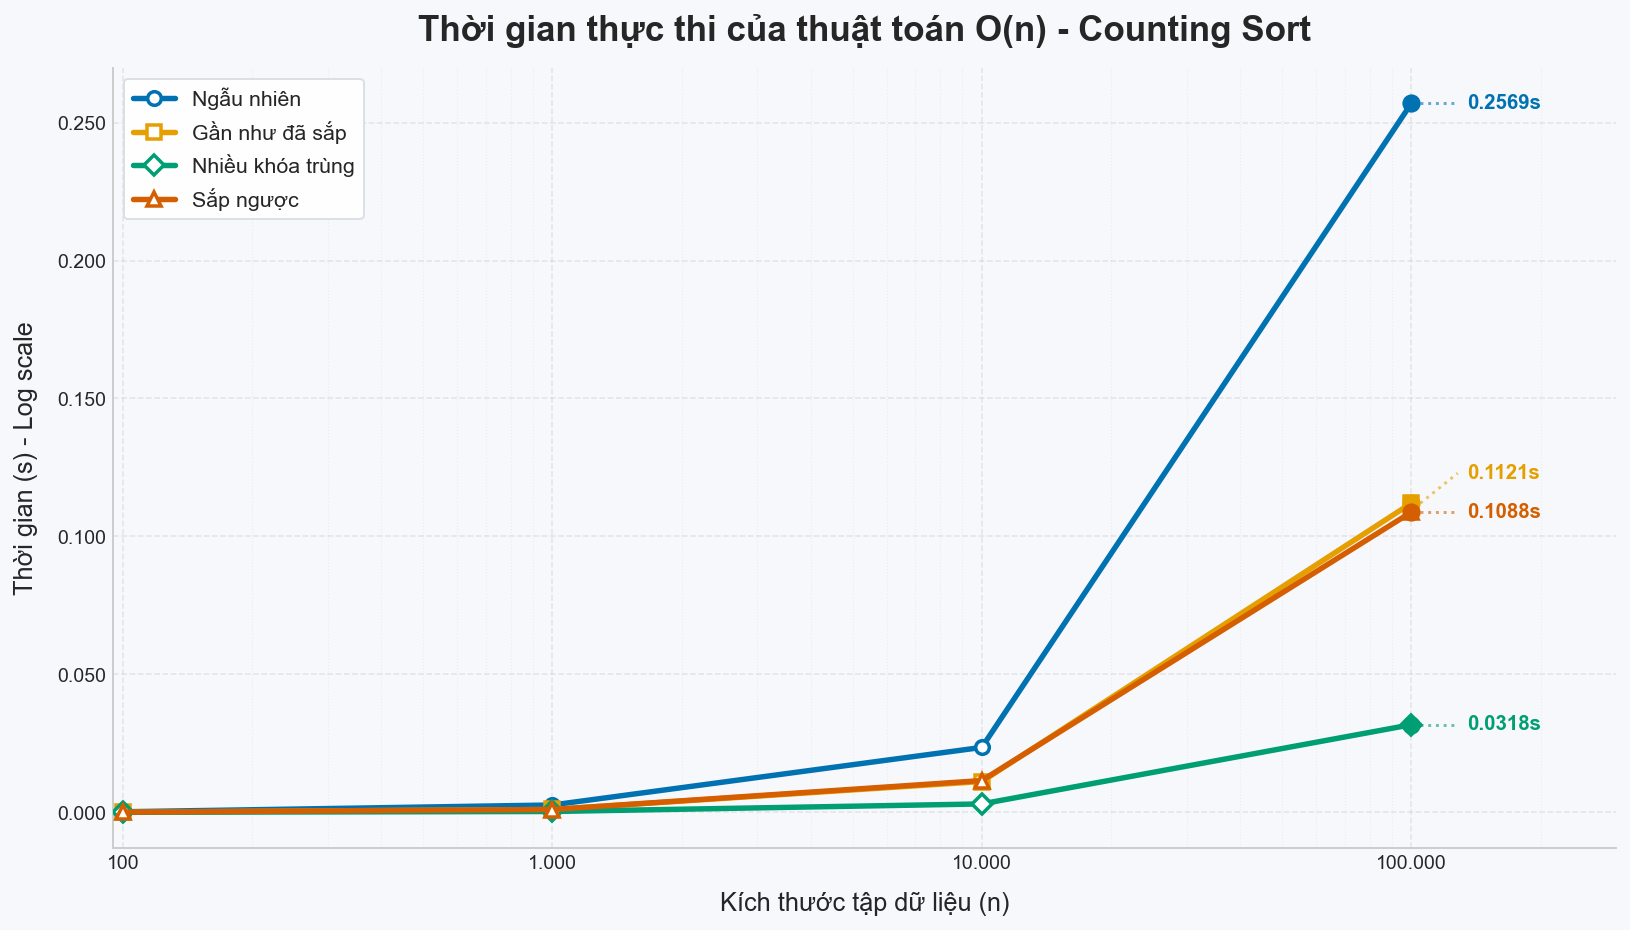

In [7]:
plot_execution_times(
    results_dict=results_n, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="O(n) - Counting Sort"
)

#### Nhận xét biểu đồ:
##### 1. Xu hướng tổng quan
* **Tăng gần tuyến tính theo kích thước dữ liệu:** Thời gian thực thi tăng đều khi `n` tăng từ 100 lên 100.000, phù hợp với bản chất `O(n + k)` của Counting Sort khi dữ liệu dạng số nguyên.
* **Khoảng cách rõ ở quy mô lớn:** Tại `n = 100.000`, sự khác biệt giữa các phân bố dữ liệu thể hiện rõ do ảnh hưởng trực tiếp của miền giá trị `k`.

##### 2. So sánh các loại dữ liệu (tại `n = 100.000`)
* **Chậm nhất - Ngẫu nhiên:** dữ liệu ngẫu nhiên có miền giá trị rộng, khiến mảng đếm lớn và chi phí khởi tạo/tái tạo tăng mạnh.
* **Nhanh nhất - Nhiều khóa trùng:** miền giá trị nhỏ, tần suất lặp cao nên Counting Sort phát huy tối đa lợi thế.
* **Gần như đã sắp** và **Sắp ngược:** có tốc độ ở mức trung gian vì miền giá trị không quá lớn như random.

##### 3. Đặc tính và kết luận
* Counting Sort **rất mạnh** khi miền khóa nhỏ hoặc nhiều phần tử trùng.
* Counting Sort **không thuần O(n) trong mọi tình huống**, vì khi `k` tăng lớn thì chi phí `O(k)` trở thành yếu tố chi phối.

### 5.2 Radix sort

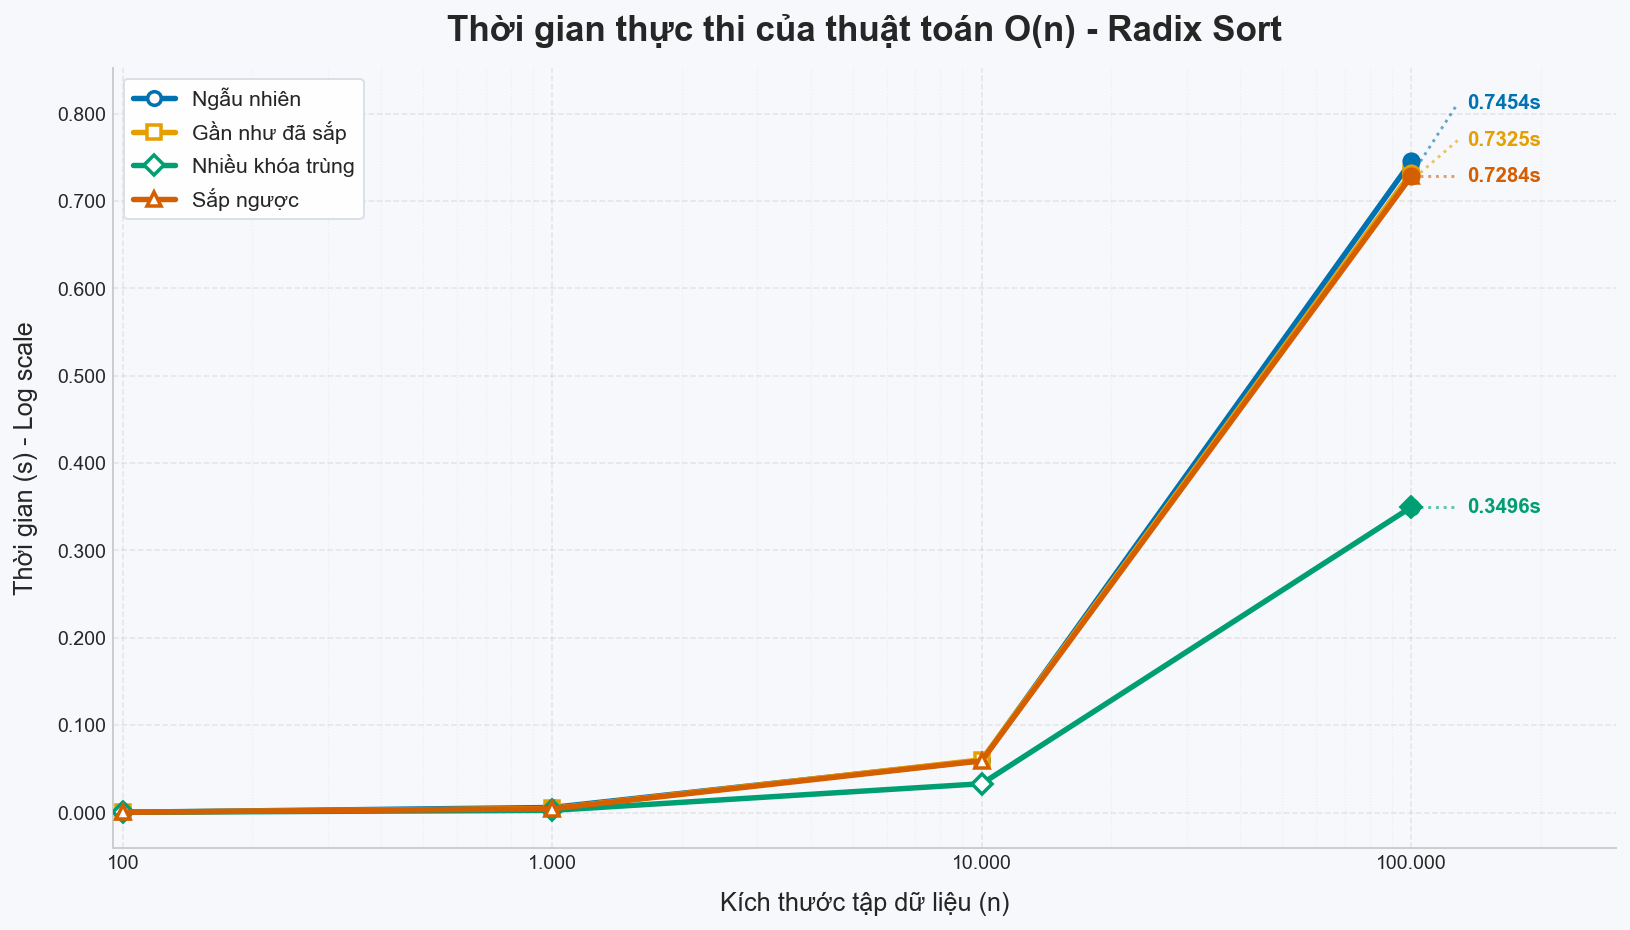

In [8]:
plot_execution_times(
    results_dict=results_n_bonus, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="O(n) - Radix Sort"
)

#### Nhận xét biểu đồ:
##### 1. Xu hướng tổng quan
* **Độ ổn định cao:** Các đường thời gian của Radix Sort nằm khá gần nhau trên cả 4 kiểu dữ liệu.
* **Tăng gần tuyến tính theo `n`:** Khi `n` tăng 10 lần, thời gian tăng tương ứng theo xu hướng tuyến tính có hằng số lớn hơn Counting Sort.

##### 2. Phân tích chi tiết tại `n = 100.000`
* **Nhanh nhất - Nhiều khóa trùng:** số chữ số hiệu dụng nhỏ hơn và thao tác phân phối bucket thuận lợi.
* **Các tập random / nearly sorted / reverse sorted:** thường sát nhau vì Radix Sort ít phụ thuộc vào thứ tự ban đầu, chủ yếu phụ thuộc vào số chữ số `d`.

##### 3. Đặc tính và kết luận
* Radix Sort thể hiện đúng tính chất thuật toán tuyến tính thực dụng: `O(d * (n + b))`.
* Với `b = 10` cố định và `d` nhỏ (3-6 chữ số), đồ thị cho thấy hành vi gần `O(n)` rõ ràng.

### Ghi nhận kết quả thực thi:

In [9]:
dir_path = "../results"
os.makedirs(dir_path, exist_ok=True)

with open(f"{dir_path}/counting_sort.json", "w") as f:
    json.dump(results_n, f)

with open(f"{dir_path}/radix_sort.json", "w") as f:
    json.dump(results_n_bonus, f)
    
print("Đã lưu kết quả O(n) thành công!")

Đã lưu kết quả O(n) thành công!


## 6. So sánh

Để có cái nhìn trực quan giữa 2 loại thuật toán, ta tiến hành so sánh chúng.

In [10]:
all_algo_results = {
    "Counting Sort": results_n,
    "Radix Sort": results_n_bonus   
}

sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']

### 6.1 Bar chart

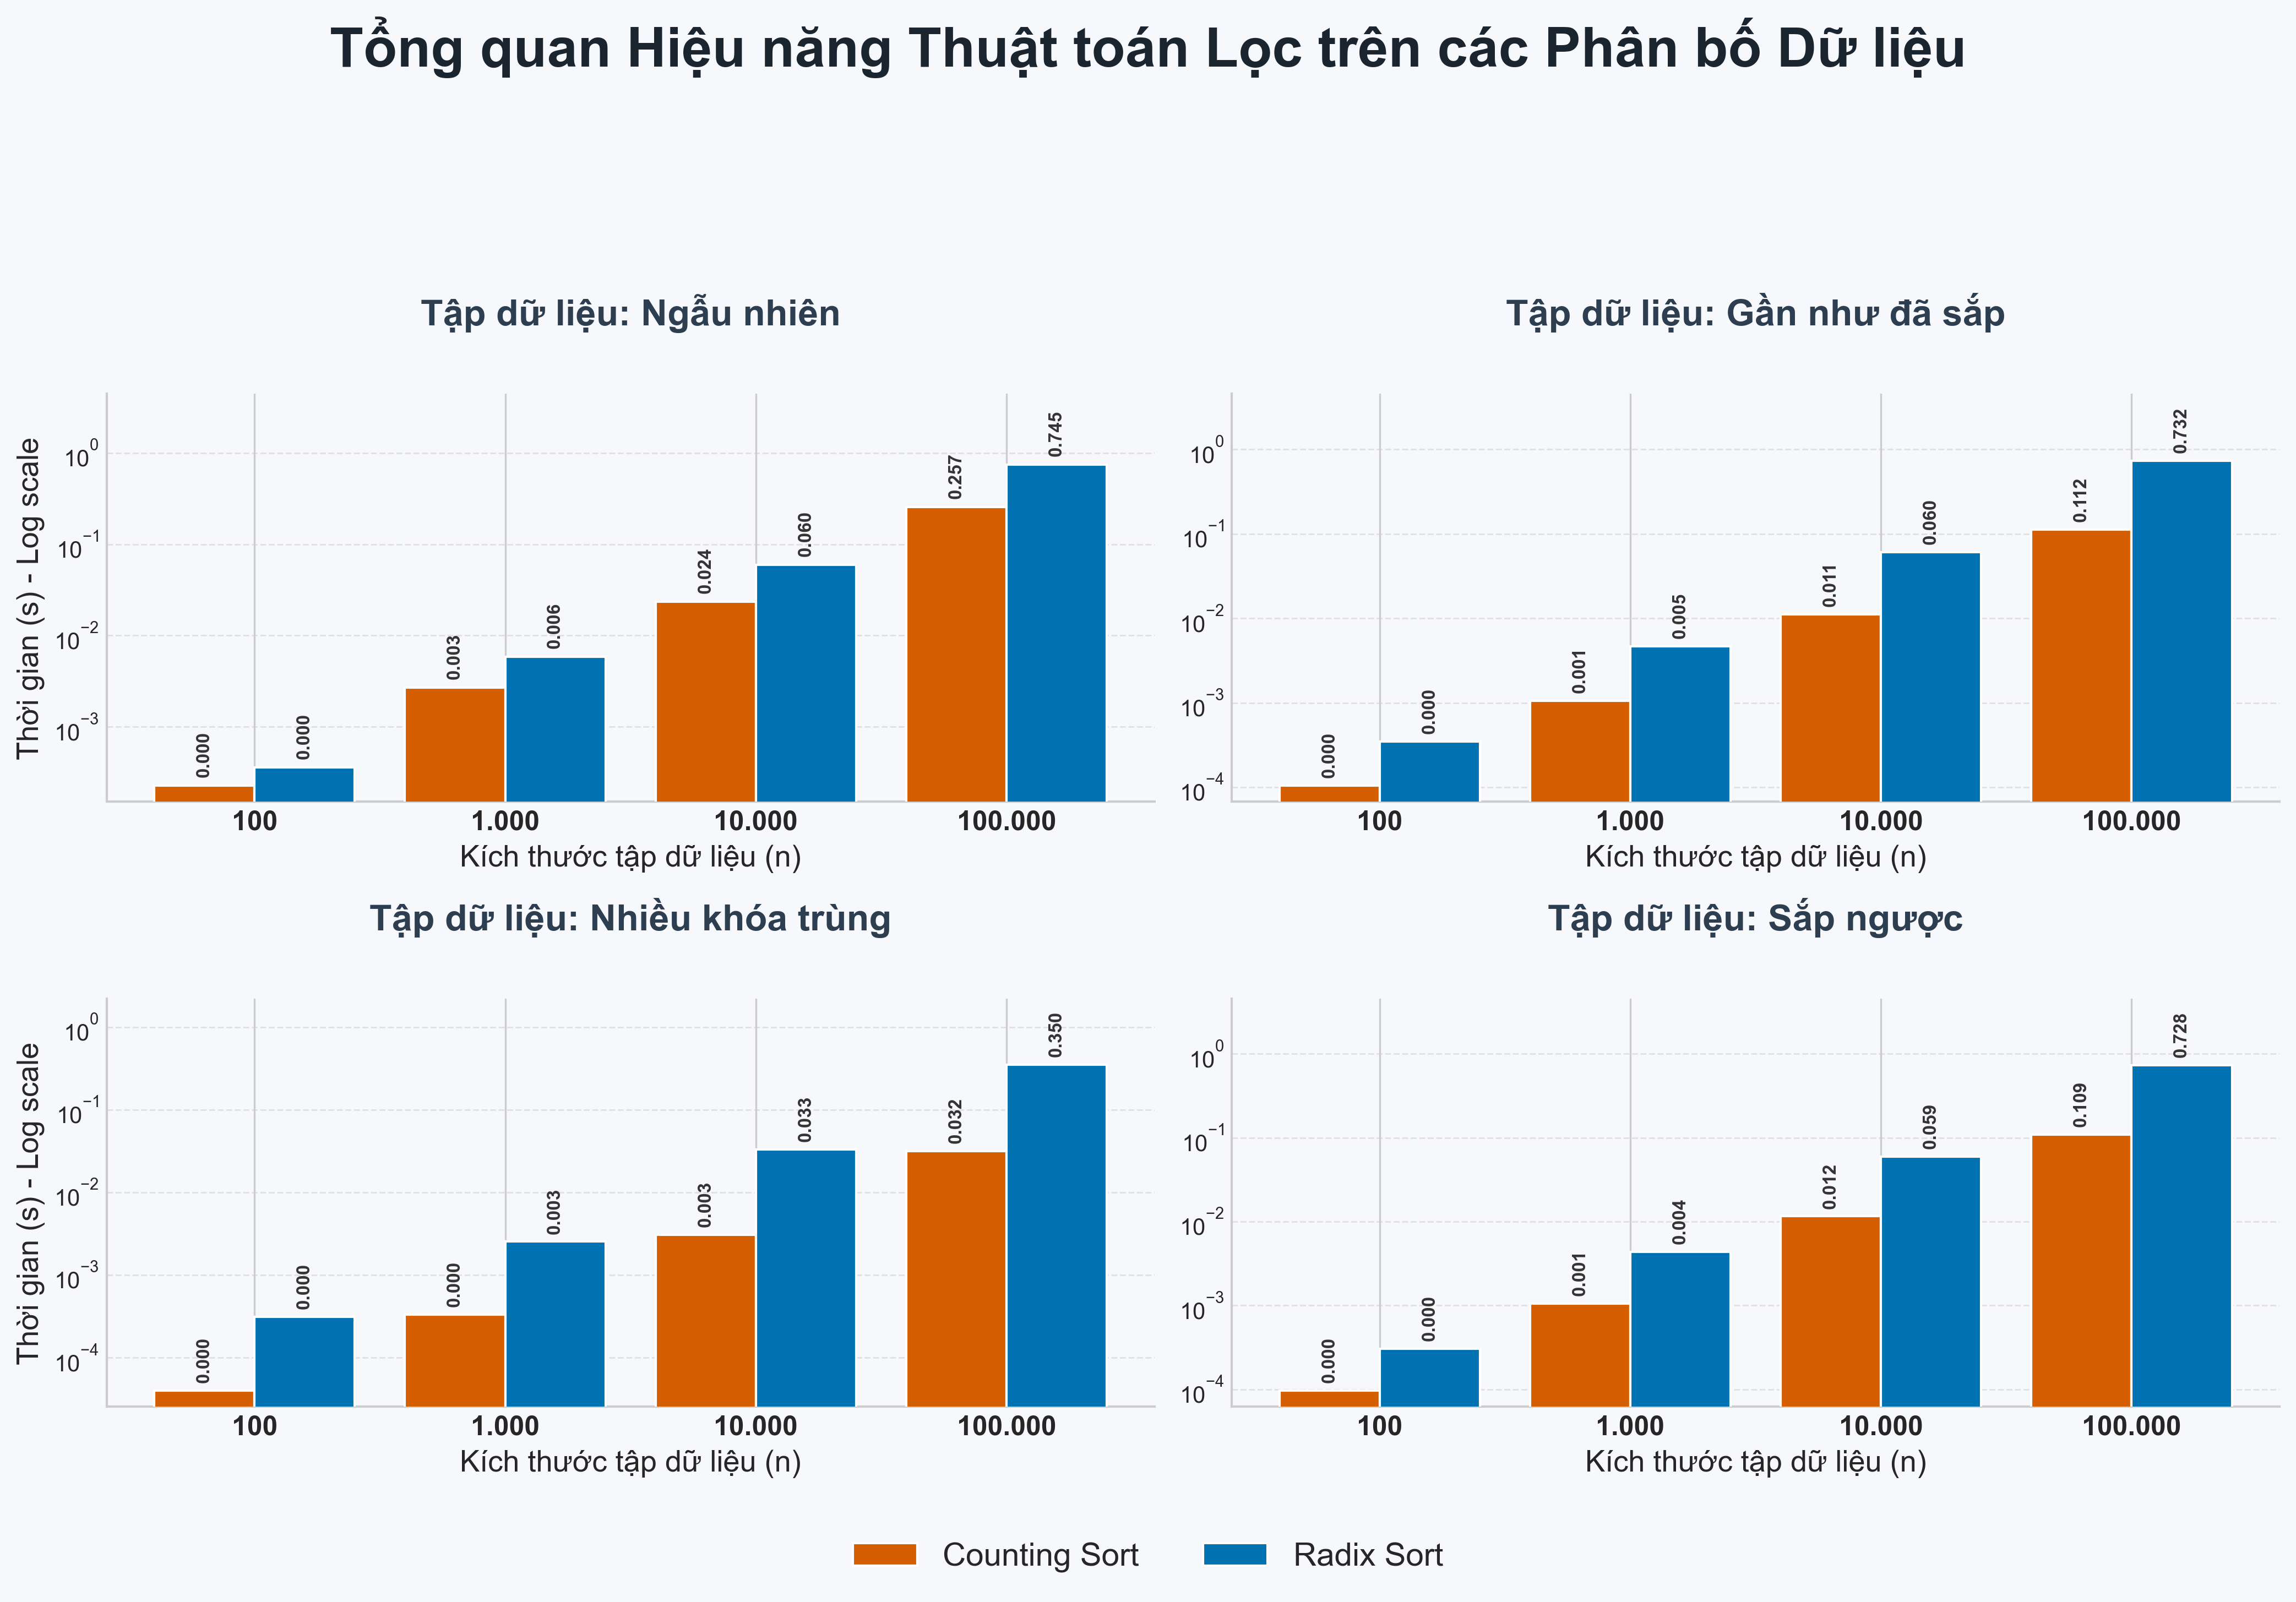

In [11]:
plot_comprehensive_barchart_grid(
    all_results=all_algo_results,
    sizes=sizes,
    datasets=datasets,
    title="Tổng quan Hiệu năng Thuật toán Lọc trên các Phân bố Dữ liệu"
)

#### Phân tích Hiệu năng Thuật toán Sắp xếp: Counting Sort vs. Radix Sort

Biểu đồ so sánh thời gian thực thi (giây) của hai thuật toán trên thang đo **Log Scale** với 4 loại phân bố dữ liệu và kích thước mảng từ 100 đến 100.000.

##### 1. Tập dữ liệu: Ngẫu nhiên (Random)
* **Quan sát:** Counting Sort chậm hơn rõ rệt khi `n` lớn do miền giá trị `k` rộng.
* **Nhận xét:** Radix Sort thường ổn định hơn trên tập random vì không cần cấp phát mảng đếm theo `max_value`.

##### 2. Tập dữ liệu: Gần như đã sắp xếp (Nearly Sorted)
* **Quan sát:** Cả hai tăng theo xu hướng tuyến tính.
* **Nhận xét:** Chênh lệch không quá lớn, nhưng Radix Sort thường nhỉnh hơn về độ ổn định khi `n` tăng cao.

##### 3. Tập dữ liệu: Nhiều khóa trùng (Many Duplicates)
* **Quan sát:** Counting Sort đạt lợi thế mạnh nhất.
* **Nhận xét:** Miền giá trị nhỏ giúp Counting Sort cực nhanh; Radix Sort vẫn tốt nhưng chịu chi phí nhiều vòng quét chữ số.

##### 4. Tập dữ liệu: Sắp xếp ngược (Reverse Sorted)
* **Quan sát:** Hai thuật toán ít bị ảnh hưởng bởi thứ tự ban đầu.
* **Kết luận:** Sự khác biệt chủ yếu đến từ đặc trưng miền giá trị, không phải mức độ đã sắp của dữ liệu.

**Tổng kết:** Counting Sort mạnh trong bối cảnh miền giá trị nhỏ, trong khi Radix Sort là lựa chọn cân bằng hơn khi miền giá trị lớn hoặc phân bố khóa đa dạng.

### 6.2 Heatmap

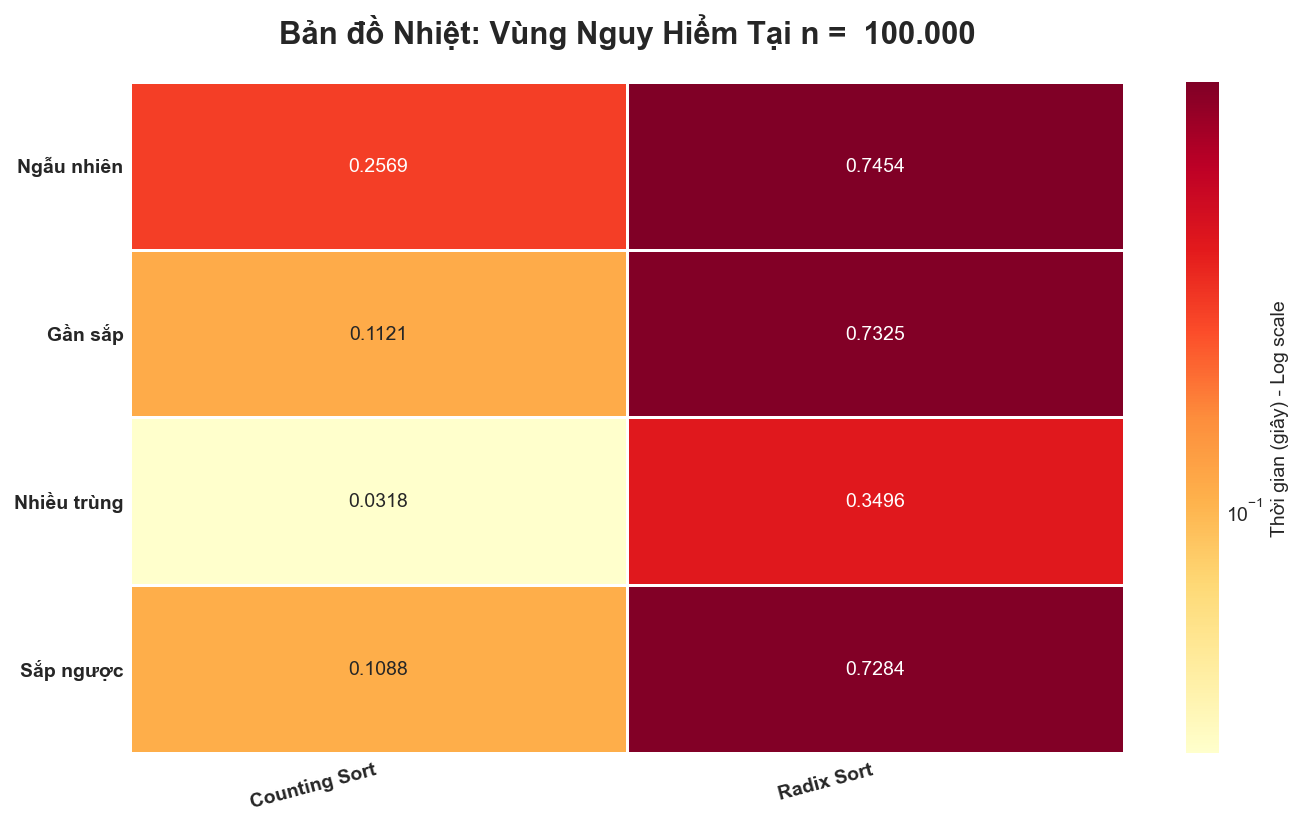

In [12]:
plot_danger_zone_heatmap(all_algo_results, 3, sizes, datasets)

### Phân tích Bản đồ Nhiệt: Hiệu năng Thuật toán tại $n = 100.000$

Heatmap cho phép nhận diện nhanh vùng nóng thời gian giữa **Counting Sort** và **Radix Sort** trên 4 kiểu dữ liệu.

##### 1. Điểm nổi bật
* Ô nóng nhất thường thuộc về **Counting Sort - Random** do miền `k` lớn.
* Ô lạnh nhất thường thuộc về **Counting Sort - Many Duplicates** nhờ miền giá trị nhỏ.
* Các ô của Radix Sort phân bố khá đồng đều, phản ánh tính ổn định giữa các phân bố đầu vào.

##### 2. Ý nghĩa kỹ thuật
* Counting Sort nhạy theo miền khóa hơn là thứ tự dữ liệu.
* Radix Sort nhạy theo số chữ số `d`, ít nhạy theo mức độ sắp xếp ban đầu.

##### 3. Kết luận
Heatmap củng cố kết luận rằng cả hai là thuật toán tuyến tính thực dụng, nhưng phù hợp với các điều kiện dữ liệu khác nhau.

### 6.3 Tỷ lệ tăng tốc của RadixSort so với CountingSort

c:\Users\huynh\Documents\SOS\MATERIAL\TQHDL\sorting-algorithms-benchmark\src\utils.py:442: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.08, 1, 0.93])
c:\Users\huynh\Documents\SOS\MATERIAL\TQHDL\sorting-algorithms-benchmark\src\utils.py:442: UserWarning: Glyph 7927 (\N{LATIN SMALL LETTER Y WITH HOOK ABOVE}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.08, 1, 0.93])
c:\Users\huynh\Documents\SOS\MATERIAL\TQHDL\sorting-algorithms-benchmark\src\utils.py:442: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.08, 1, 0.93])
c:\Users\huynh\Documents\SOS\MATERIAL\TQHDL\sorting-algorithms-benchmark\src\utils.py:442: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.08, 1, 0.93])
c:\Users\huynh\Documents\SOS\MATERIAL\TQHDL\sorting-algo

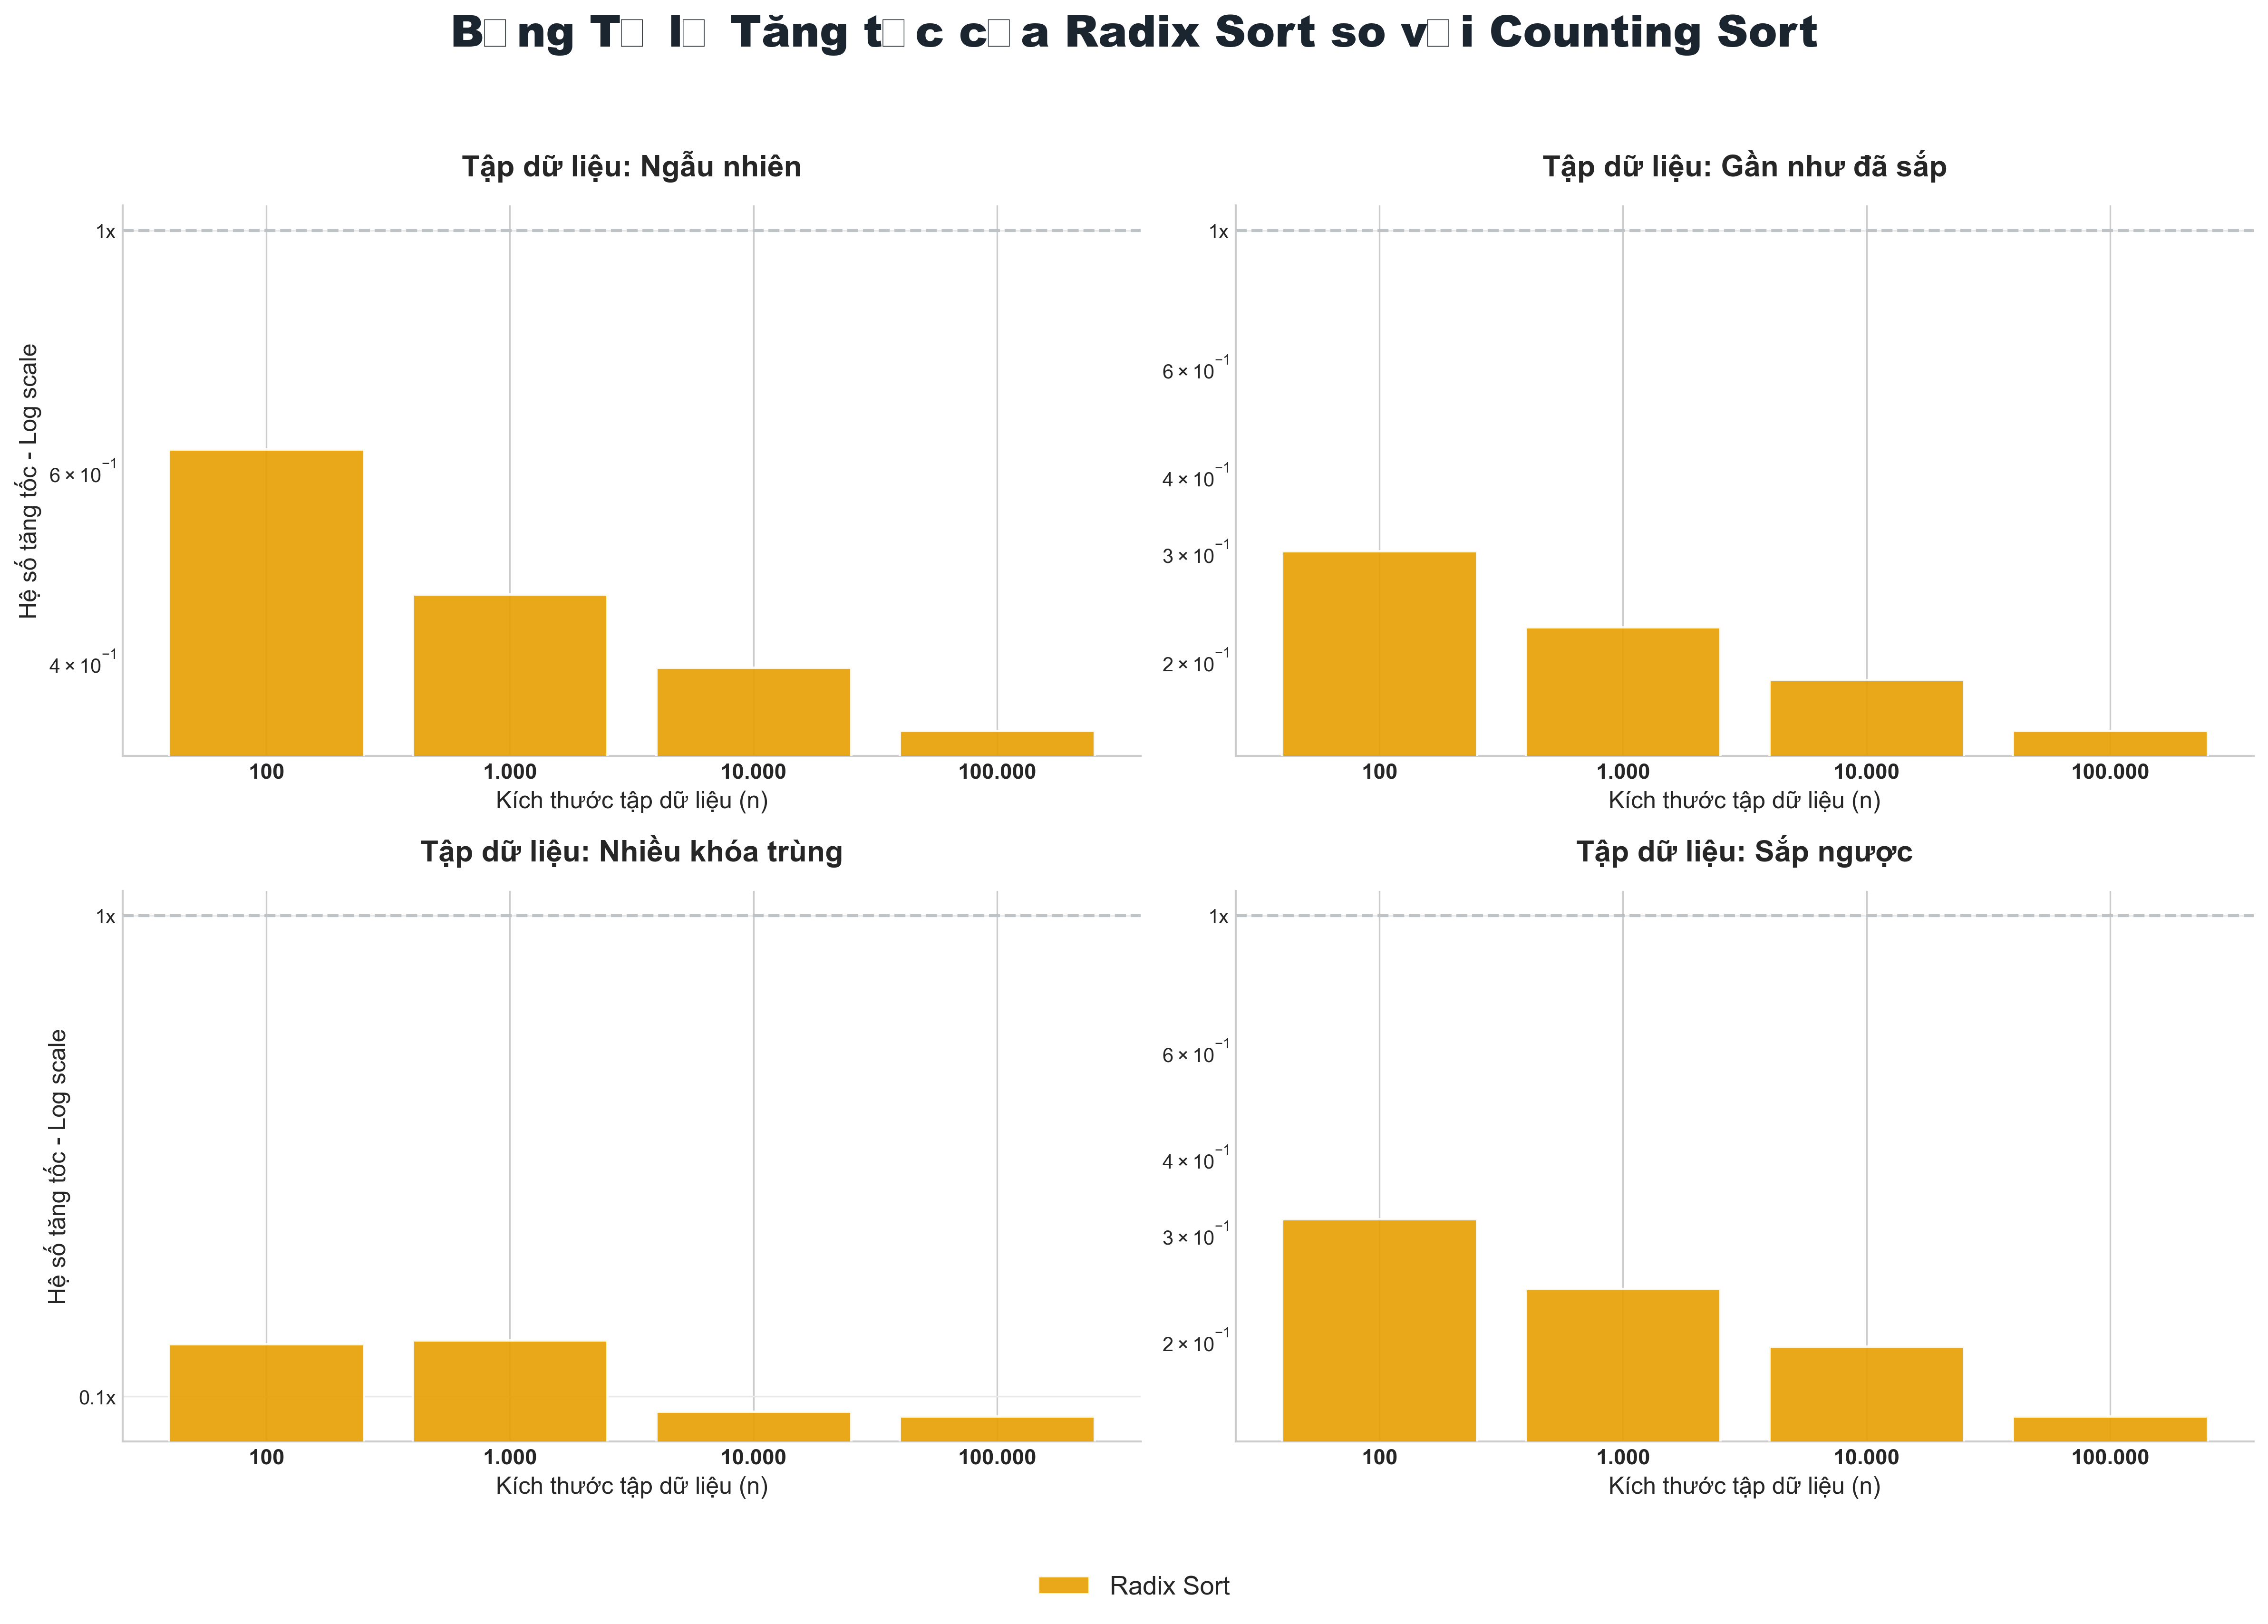

In [13]:
plot_algorithm_speedup_grid(
    all_algo_results,
    sizes,
    datasets,
    baseline_algo_name="Counting Sort",
    title="Bảng Tỷ lệ Tăng tốc của Radix Sort so với Counting Sort"
)

### Phân tích Biểu đồ Tỷ lệ Tăng tốc: Radix Sort vs. Counting Sort

Trong biểu đồ này, đường **1x** là mốc tham chiếu của **Counting Sort**.
* Cột **trên 1x**: Radix Sort nhanh hơn Counting Sort.
* Cột **dưới 1x**: Radix Sort chậm hơn Counting Sort.

##### 1. Dữ liệu Ngẫu nhiên (Random)
* Radix Sort thường nằm trên 1x ở quy mô lớn.
* **Kết luận:** Radix Sort có lợi thế khi miền giá trị random rộng, nơi Counting Sort tốn chi phí `k`.

##### 2. Dữ liệu Gần như đã sắp (Nearly Sorted)
* Tỷ lệ gần 1x hoặc nhỉnh hơn nhẹ.
* **Kết luận:** Hai thuật toán khá cạnh tranh, không có chênh lệch áp đảo.

##### 3. Dữ liệu Nhiều khóa trùng (Many Duplicates)
* Tỷ lệ thường dưới 1x.
* **Kết luận:** Counting Sort chiếm ưu thế mạnh do miền khóa nhỏ.

##### 4. Dữ liệu Sắp ngược (Reverse Sorted)
* Tỷ lệ dao động quanh 1x.
* **Kết luận:** Cả hai ít bị ảnh hưởng bởi thứ tự ban đầu.

**Tổng kết:** Radix Sort phù hợp khi cần hiệu năng ổn định trên nhiều phân bố, còn Counting Sort tối ưu nhất khi miền giá trị hẹp.

## 7. Baseline

### Phương pháp Trích xuất Đường cơ sở (Baseline) đại diện

Để tạo đường cơ sở đại diện cho nhóm **O(n)**, nhóm tổng hợp toàn bộ kết quả từ hai thuật toán tuyến tính đã kiểm thử.

**Quy trình thực hiện:**

1. Thu thập đầy đủ kết quả của **Counting Sort** trên 4 phân bố dữ liệu.
2. Thu thập đầy đủ kết quả của **Radix Sort** trên 4 phân bố dữ liệu.
3. Với mỗi kích thước `n`, tính **trung bình cộng** của 8 giá trị hợp lệ (2 thuật toán x 4 phân bố).

Cách làm này giúp đường baseline phản ánh xu hướng trung tâm của toàn nhóm O(n), giảm thiên lệch do một thuật toán hay một phân bố dữ liệu riêng lẻ.

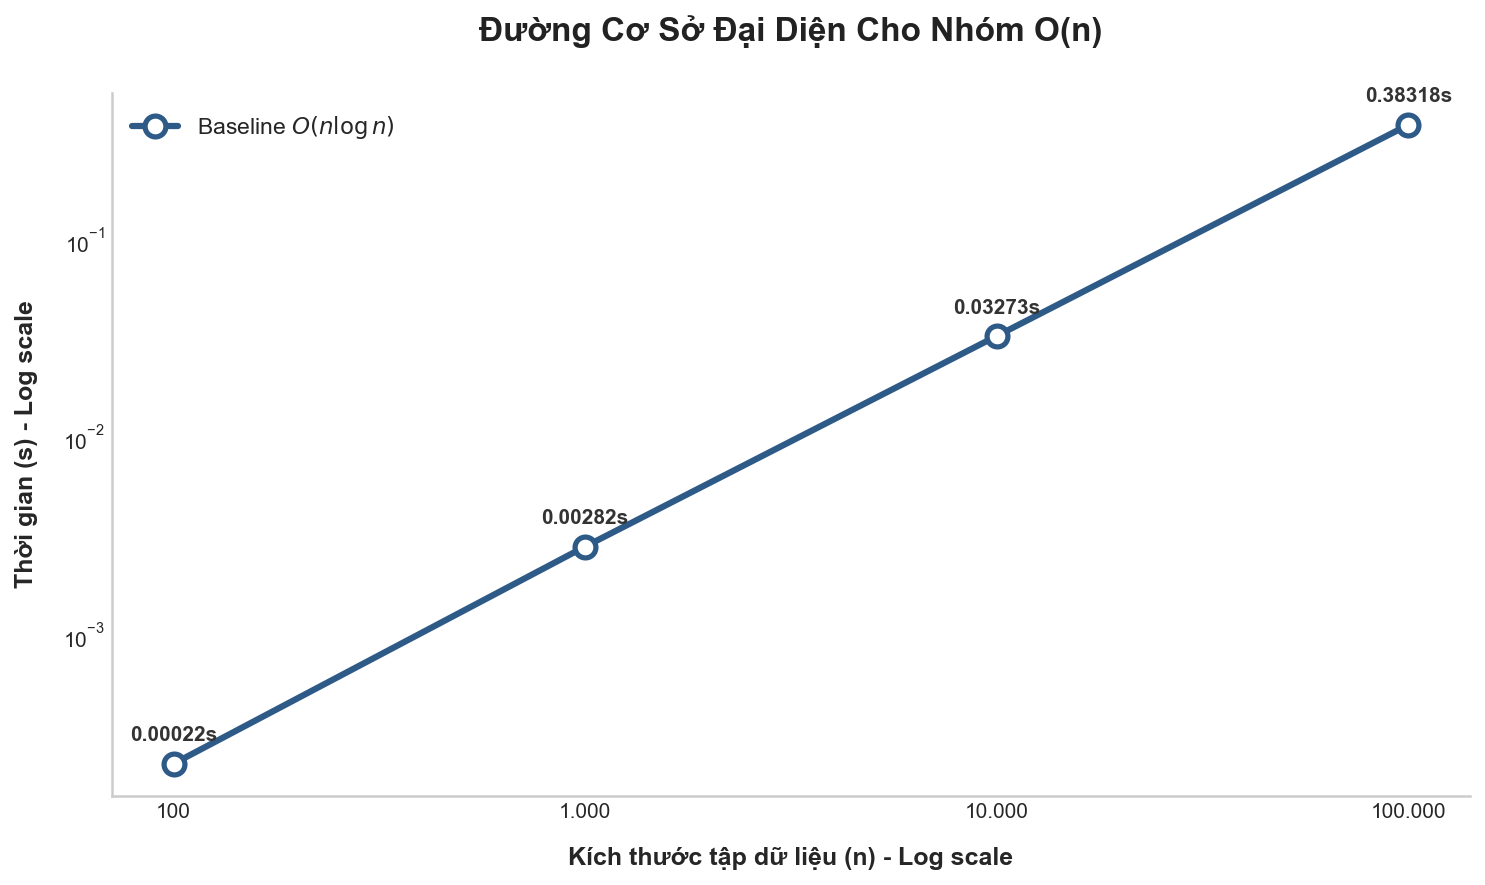

In [14]:
# Tính toán Baseline O(n)
baseline_results = []

for i in range(len(sizes)):
    valid_times = []
    for algo_name in all_algo_results:
        for ds in datasets:
            t = all_algo_results[algo_name][ds][i]
            if t is not None:
                valid_times.append(t)

    baseline_results.append(sum(valid_times) / len(valid_times) if valid_times else None)

plot_baseline_n_log_n(sizes, baseline_results, title="Đường Cơ Sở Đại Diện Cho Nhóm O(n)")

#### Nhận xét biểu đồ: Đường Cơ Sở Đại Diện Cho Nhóm O(n)

Biểu đồ baseline cho thấy xu hướng tăng trưởng gần tuyến tính của nhóm thuật toán O(n) khi kích thước dữ liệu tăng theo cấp số 10.

##### 1. Xu hướng tăng trưởng
* Trên thang log-log, đường biểu diễn gần đường thẳng, phù hợp với bản chất tuyến tính có hệ số phụ.
* Mức tăng từ `n=10.000` lên `n=100.000` vẫn giữ hình thái ổn định, không có dấu hiệu bùng nổ như nhóm `O(n^2)`.

##### 2. Ý nghĩa baseline
* Baseline này là mốc tham chiếu để so sánh chéo với baseline của nhóm `O(n log n)` và `O(n^2)`.
* Thuật toán nào nằm thấp hơn baseline O(n) ở cùng quy mô dữ liệu được xem là tối ưu hơn trong bối cảnh thực nghiệm.

**Kết luận:** Baseline O(n) phản ánh đúng đặc trưng hiệu năng nhanh và ổn định ở dữ liệu lớn của nhóm thuật toán tuyến tính.

#### Ghi nhận kết quả

In [15]:
with open(f"{dir_path}/baseline_O_n.json", "w") as f:
    json.dump(baseline_results, f)

print("Đã xuất dữ liệu thành công ra file: baseline_O_n.json")

Đã xuất dữ liệu thành công ra file: baseline_O_n.json
